## **Name:** Nico Montoya

## **Computing ID:** zzm5rx

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import precision_score, recall_score, accuracy_score

!pip install lime
from lime import lime_tabular
from sklearn.inspection import permutation_importance

# Below is a new package needed for this lab
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# Lab 3: Decision Trees and Random Forests (100 Points)
## **Due November 10th, 2025 at 11:59PM**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/17jL6-gLQWYkZJZGzAduIlU4YET0u2Ek-?usp=sharing)

The goal of this lab is to optimize Decision Tree and Random Forest models using the provided dataset on census level data. Your goal is to build a Random Forest Classifier to be able to predict income levels above or below 50k.

The guidance this week is less prescriptive in terms of steps, so use the skills you have gained over the semester to build and evaluate your models. You will be graded on your model building, interpretation of the results and explanation of model selection. As always, you are welcome to rely on your classmates but submit your own code. Lastly, there are likely several correct approaches involving a variety of different conclusions, just make sure your conclusions are supported by your approach.


The dataset should be familiar as it's the census data, on 48,000+ individuals with a variety of variables and a target variable for above or below 50k in salary.

![](https://www.coopercenter.org/sites/default/files/styles/wide/public/wordpress_import/Figure1CesnsuBlog2-1024x512_0.png?itok=DwYqkfFm)

Look through the data dictionary at its source link: https://archive.ics.uci.edu/ml/datasets/Adult

# **Part 1: Data Preparation and EDA (15 points)**

In a text cell, answer the following exploratory questions and support your observations with any code, if needed.

## **Question 1 (2 points):**
## Read in the features (X) as a Pandas DataFrame. Show the first 5 rows of the features. How many rows do you have?



In [2]:
# Fetch dataset
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

In [3]:
print(X.head())
print(X.shape[0])

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country  
0          2174             0              40  United-States  
1             0             0              13  United-St

**There is a total of 48842 rows and 14 features**

## **Question 2 (2 points):**
## Are there any potential issues in the data or target that need to be corrected? Why are they issues? What specific method would you use to correct them and why?

## Consider using code and reading the data description (https://archive.ics.uci.edu/dataset/2/adult) to explore:

*   Assumptions and ranges of collected data
*   Missing values (impute? drop?)
*   Numerical data types represented as strings
*   Encoding categorical data appropriately
*   Normalization
*   Standardization

## You will not need to consider feature imbalances or sampling in part 1 or 2 of the lab.

In [4]:
display(X.dtypes)
display(X.isna().sum())
display(y.isna().sum())

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


,0
income,0


**Potential Issues:** Potential issues I've identified are....missing data that have not coded properly to NaN which can cause errors in data analysis, many columns you strings or text to describe there data which cannot be interpreted by machine learning since it is not numerical, there are two education columns, since they represent the same thing only one needs to stay, target variable is also currently stored as text so will also have to change that to be binary as well.

## **Question 3 (6 points):**
## Preprocess the data according to the issues and correction methods you've identified. Save the new features and target variable (if necessary) as X_clean and y_clean.

In [5]:
X = X.replace("?", pd.NA)
X.loc[:, ["workclass", "occupation", "native-country"]] = (
    X[["workclass", "occupation", "native-country"]].fillna("Unknown"))
X_clean = X.dropna().reset_index(drop=True)
X_clean = X.drop(columns=["education"])
for col in X_clean.select_dtypes(include=['object']):
    X_clean[col] = X_clean[col].astype("category")

# Make sure X and y are alligned
y_clean = y.loc[X_clean.index].reset_index(drop=True)

## **Question 4 (5 points):**
## Create 2 versions of y_clean to create a new target response of whether income is above or below $50,000 for classification.

1.   **y_clean_binary:** Recode y_clean to be 1 if the target is over or equal to 50,000
2.   **y_clean_string:** Recode y_clean to be "Above or Equal" if the target is over or equal to 50,000 and "Below" if under.



In [6]:
y_clean = y_clean.replace({">50K.": ">50K", "<=50K.": "<=50K"})
y_clean_binary = y_clean.replace({">50K": 1, "<=50K": 0})
y_clean_string = y_clean.replace({">50K": "Above or Equal", "<=50K": "Below"})

/tmp/ipython-input-1213941210.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_clean_binary = y_clean.replace({">50K": 1, "<=50K": 0})


# **Part 2: Decision Tree Pruning, Tuning and Evaluation (30 Points)**

## **Question 1 (5 points):**
## Create a function to take in a feature variable (X) and (y). In this function, do the following:
* Create a train test split with a random seed of 3001.
* Use a vanilla decision tree model to fit the model on the train set and predict on the test set.
* Print the precision, recall, and accuracy of the model after prediction.

## Test your function on both y_clean_binary and y_clean_string. For any of the following questions, you may use whichever y_clean variable you'd like.


In [7]:
X_encoded = pd.get_dummies(X_clean, drop_first=False)
def eval_dt(X, y, pos_label=1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=3001)
    dt = DecisionTreeClassifier(criterion="gini",random_state=3001)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=pos_label)
    recall = recall_score(y_test, y_pred, pos_label=pos_label)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
print(eval_dt(X_encoded, y_clean_binary))
print(eval_dt(X_encoded, y_clean_string,pos_label='Above or Equal'))


Accuracy:  0.8141
Precision: 0.6051
Recall:    0.6203
None
Accuracy:  0.8143
Precision: 0.6055
Recall:    0.6212
None


## **Question 2 (5 points):**
## Adjust your function to include some plotting features. After your prediction code, plot:

1.   A visualization of the resulting Decision Tree
2.   A confusion matrix of the results

## Your tree might be overwhelming or very large! If it is too large to be interpreted, constrain the max_depth parameter manually to 5 or less.

In [8]:
def eval_dt(X, y, pos_label=1, max_depth=None):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=3001)

    dt = DecisionTreeClassifier(random_state=3001, max_depth=max_depth)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=pos_label)
    recall = recall_score(y_test, y_pred, pos_label=pos_label)

    print(f"Results (max_depth={max_depth})")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")

    feature_names = X.columns.tolist()
    class_names = [str(c) for c in dt.classes_]

    plt.figure(figsize=(20, 10))
    plot_tree(dt,feature_names=feature_names,class_names=class_names,filled=True,rounded=True,fontsize=8)
    plt.title(f"Decision Tree (max_depth={max_depth})")
    plt.show()


    ConfusionMatrixDisplay.from_estimator(dt,X_test,y_test,display_labels=class_names,cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

Results (max_depth=5)
Accuracy:  0.8485
Precision: 0.7675
Recall:    0.5175


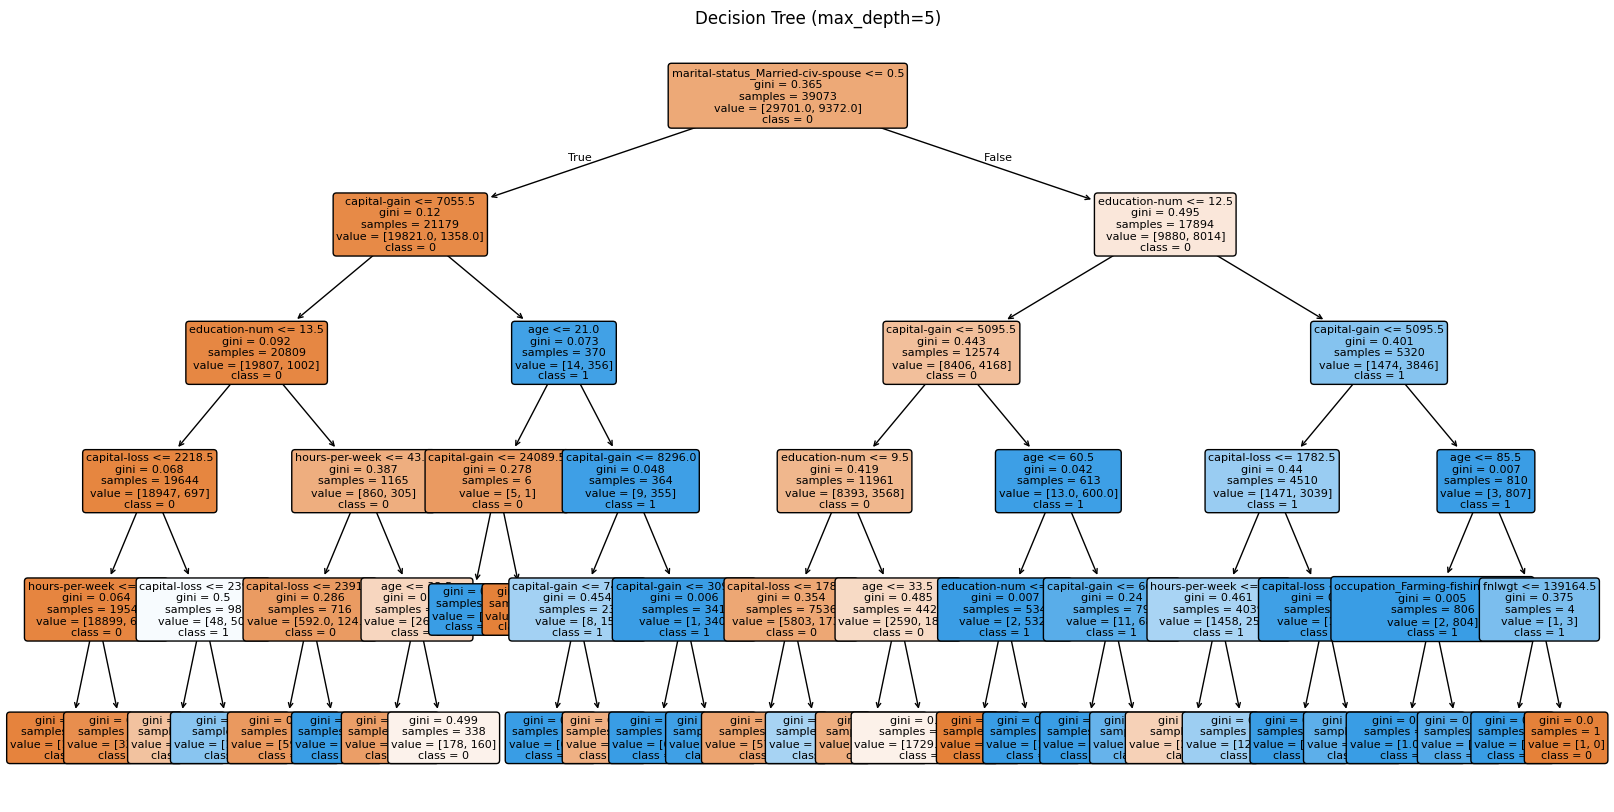

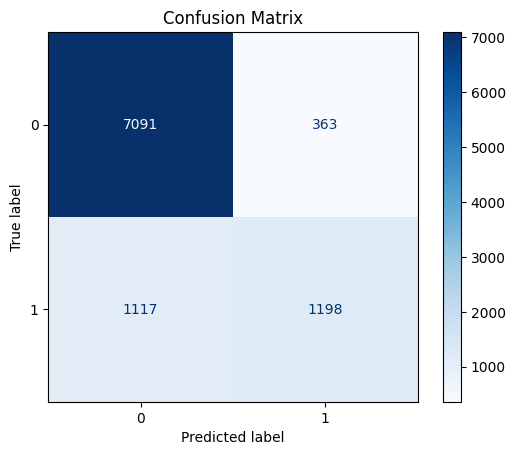

In [9]:
eval_dt(X_encoded, y_clean_binary, max_depth=5)

## **Question 3 (5 points):**
## Create a sorted list of feature importances and comment on the top features.Plot your feature importances in a horizontal or vertical bar chart from most to least important. Label each bar with its feature importance rounded to the nearest integer (ie: 30%).

## Are there a few that seem to be more important than the others?

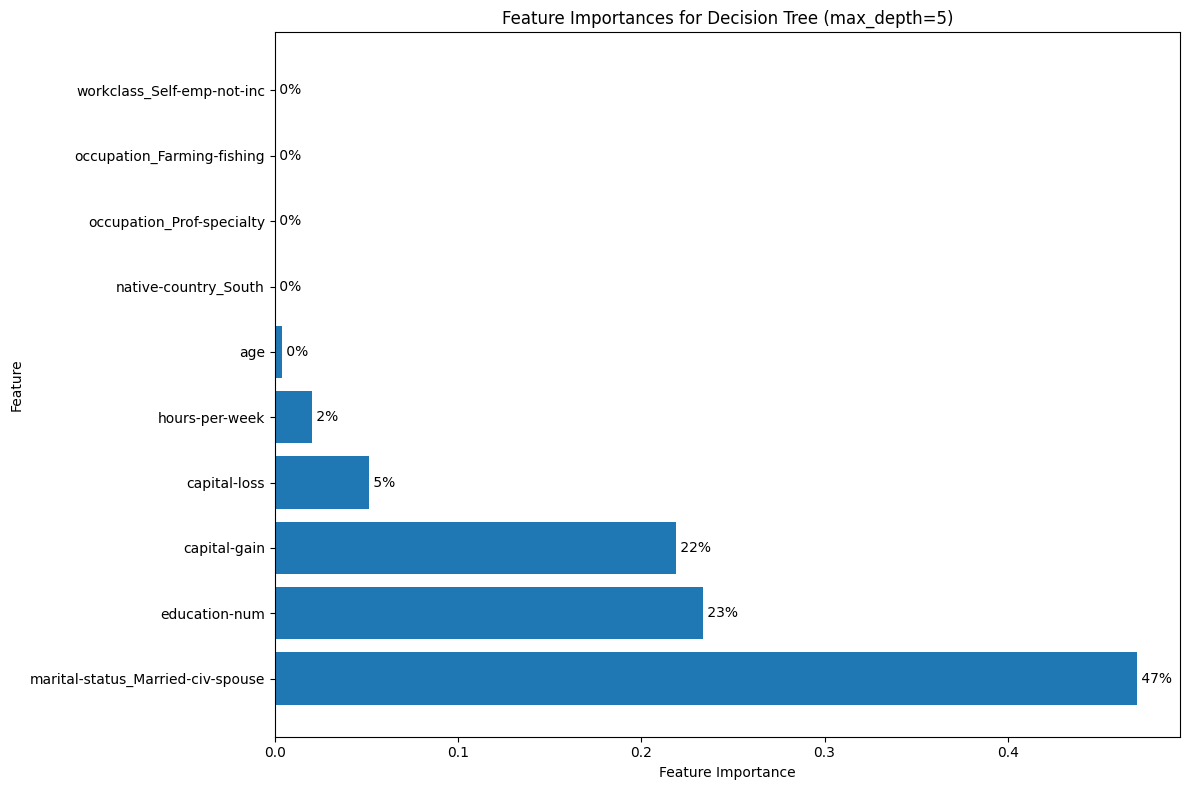

In [10]:
dt_bin = DecisionTreeClassifier(criterion="gini",random_state=3001, max_depth=5)
dt_bin.fit(X_encoded, y_clean_binary)
importances = dt_bin.feature_importances_
feature_names = X_encoded.columns

feat_imp_df = pd.DataFrame({'feature': feature_names,'importance': importances})
feat_imp_df_sorted = feat_imp_df.sort_values(by='importance', ascending=False)

plot_df = feat_imp_df_sorted[feat_imp_df_sorted['importance'] > 0]
plt.figure(figsize=(12, 8))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importances for Decision Tree (max_depth=5)")
for index, value in enumerate(plot_df['importance']):
    label = f" {value*100:.0f}%"
    plt.text(value, index, label, va='center')
plt.tight_layout()
plt.show()

**Yes, the features than stand out more in comparison to others are "marital-status_Married-civ-spouse","education-num" and "capital-gain".**

## **Question 4 (5 points):**
## Write at least 5 sentences interpreting the results of your decision tree, confusion matrix, and feature importance visualizations.

## Is there any aspect of your results that you are uncertain or unsure of?

**My results show that the most important features to my data are marital-status_Married-civ-spouse, education-num and capital-gain. These results make sense since added a person to a household or people with higher levels of education tend to be associated with higher incomes as they have more access to higher paying jobs compared to single people that are working with one income or lower education that don't have such access. The confusion matrix shoes us that the model is fairly good at predicting if a set of data will have an income lower than 50k but when when predicted if their income will be higher the just about get it wrong as often as we get it right. This is backed by our decision tree as it also show the same 3 important features often as well as the tendency to predict incomes lower than 50k better. I'm not entirely sure if one hot encoding was the way to go since there are so many categorical variables which might have downplayed the impact that some of these features might have actually had as shown by the fact the my original feature important had a lot of columns that had no importance that were encoded before making it more concise the just fit the top 10.**

## **Question 5 (5 points):**
## Finally, we will create a new function to tune your decision tree to get more accurate and efficient results. Update your function to take in several new parameters with these default values:
* criterion_val ='gini'
* splitter_val ='best'
* max_depth_val = None
* min_samples_split_val = 2
* min_samples_leaf_val =1

## Pass your own variable into the decision tree by specifying what sklearn parameter you are trying to tune. This will simply be the parameter without the "_val" suffix.

## **For example, if your vanilla decision tree variable is called clf, you would adjust it like this:**
`clf = DecisionTreeClassifier(criterion=criterion_val, splitter=splitter_val, ...)`

In [23]:
def tuned_dt(X, y,criterion_val="gini",splitter_val="best",max_depth_val=None,
             min_samples_split_val=2,min_samples_leaf_val=1,test_size=0.2,
             random_state=3001):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    tuned = DecisionTreeClassifier(
        criterion=criterion_val,
        splitter=splitter_val,
        max_depth=max_depth_val,
        min_samples_split=min_samples_split_val,
        min_samples_leaf=min_samples_leaf_val,
        random_state=random_state)
    tuned.fit(X_train, y_train)

    y_pred = tuned.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"Results (max_depth={max_depth_val})")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")

    feature_names = X.columns.tolist()
    class_names = [str(c) for c in tuned.classes_]

    plt.figure(figsize=(20, 10))
    plot_tree(tuned,feature_names=feature_names,class_names=class_names,filled=True,rounded=True,fontsize=8)
    plt.title(f"Decision Tree (max_depth={max_depth_val})")
    plt.show()

    ConfusionMatrixDisplay.from_estimator(tuned,X_test,y_test,cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    importances = pd.Series(tuned.feature_importances_, index=X.columns)
    top_importances = importances.nlargest(10)

    plt.figure(figsize=(8, 6))
    plt.barh(top_importances.index[::-1], top_importances.values[::-1])
    plt.xlabel("Feature Importance")
    plt.title("T10 Feature Importances")
    for i, v in enumerate(top_importances.values[::-1]):
        plt.text(v + 0.001, i, f"{int(round(v * 100))}%", va="center")
    plt.show()

    return tuned

Results (max_depth=5)
Accuracy:  0.8485
Precision: 0.7675
Recall:    0.5175


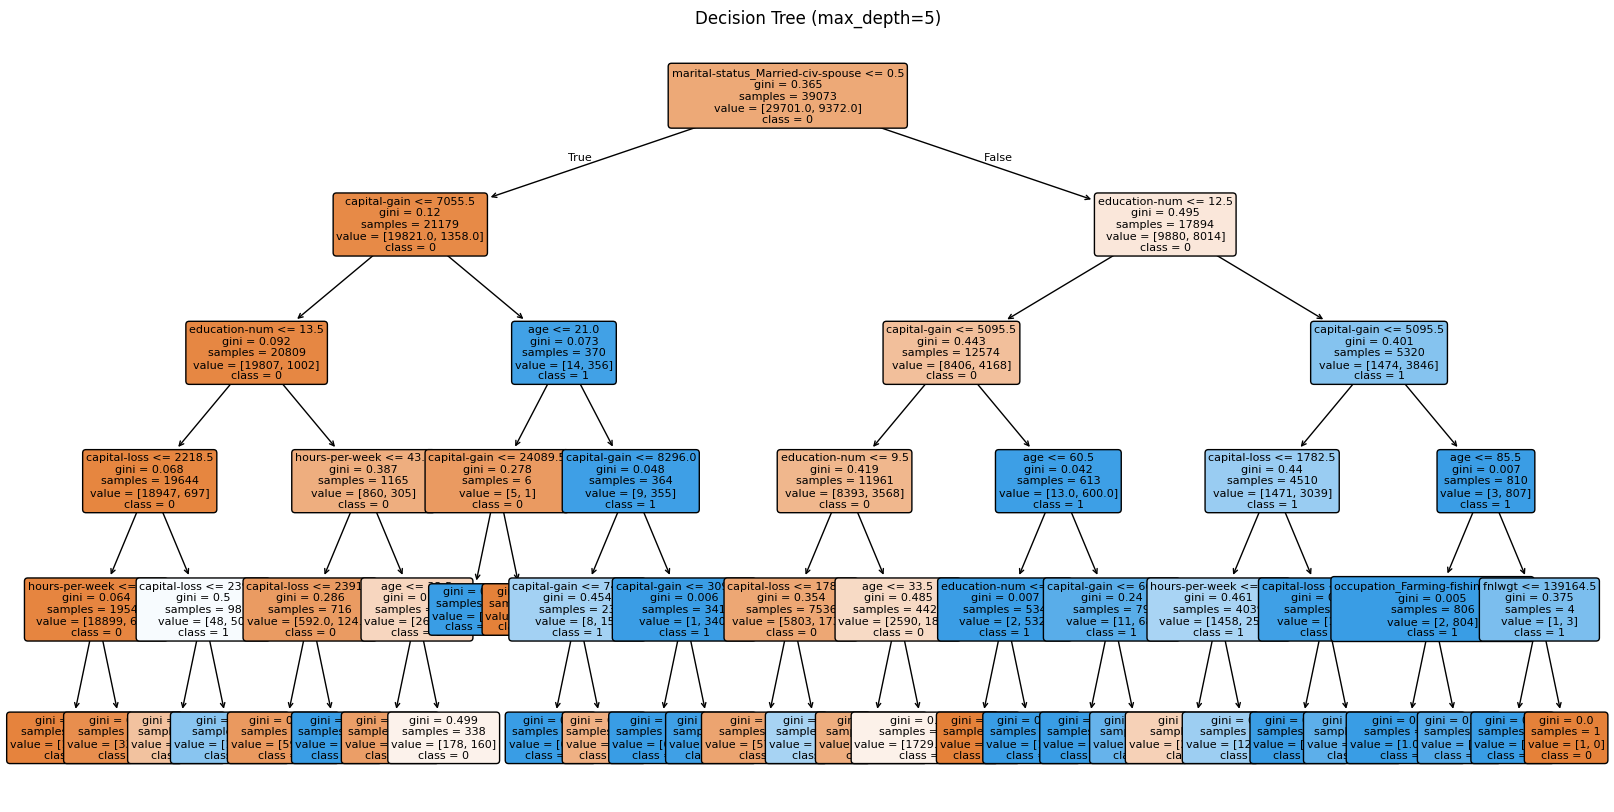

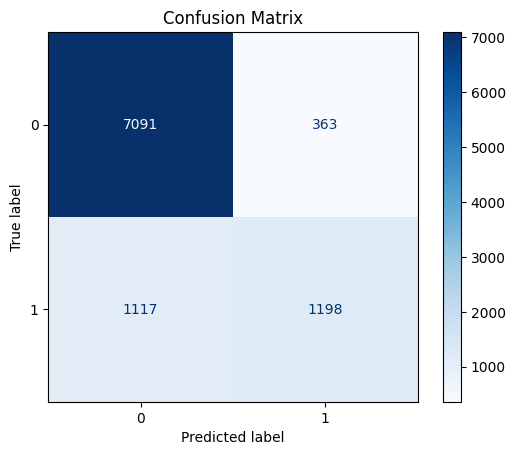

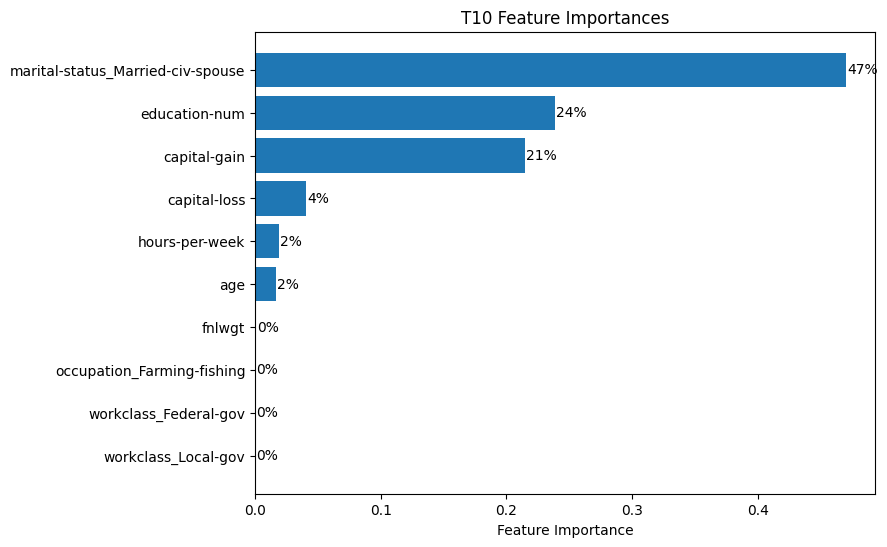

In [27]:
tuned_tree = tuned_dt(X_encoded, y_clean_binary,max_depth_val=5)
#couldn't use default value none for max depth bc the decision tree wouldn't load

## **Question 6 (5 points):**

## Call your new function with either clean y variable at least 3 times. Each time, vary the values for all the parameters and examine its effects on your tree, confusion matrix, and metrics.

You will likely want to look at documentation to see accepted values: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Why did you pick the values you did? What combination had the best effect on accuracy? Were you surprised by any of the results?

Results (max_depth=4)
Accuracy:  0.8435
Precision: 0.7191
Recall:    0.5684


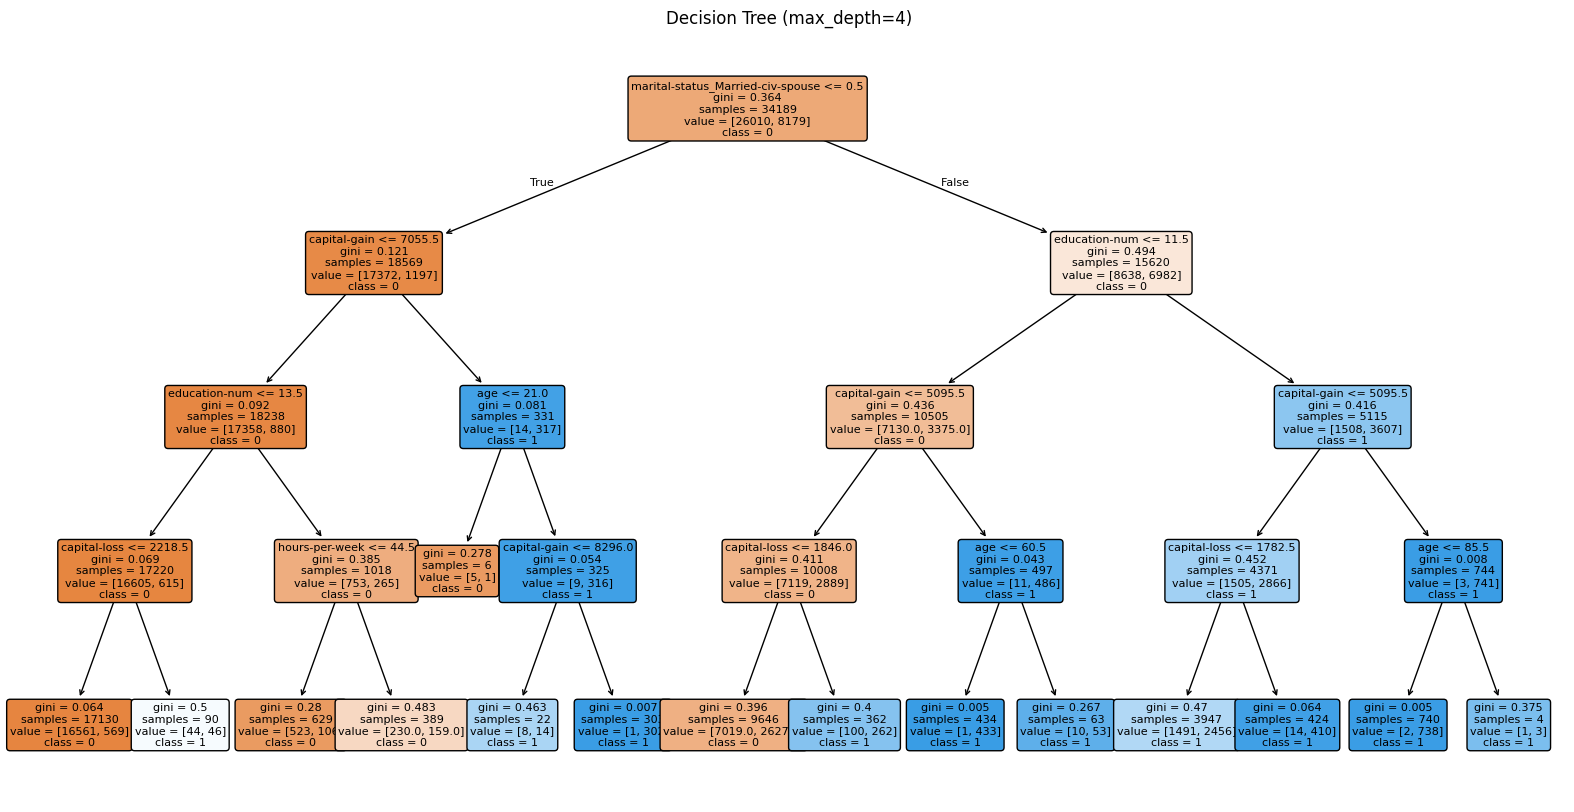

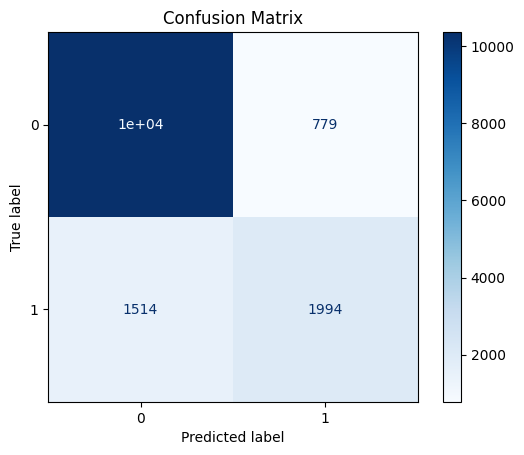

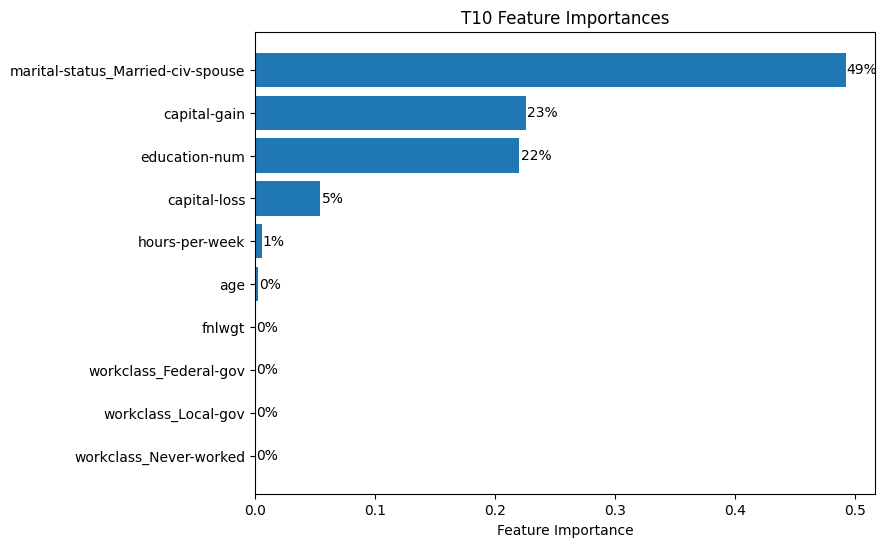

In [28]:
#First
tuned_tree1 = tuned_dt(X_encoded, y_clean_binary,criterion_val="gini",splitter_val="best",max_depth_val=4,
             min_samples_split_val=4,min_samples_leaf_val=4,test_size=0.3,random_state=3001)

Results (max_depth=7)
Accuracy:  0.8558
Precision: 0.8018
Recall:    0.5268


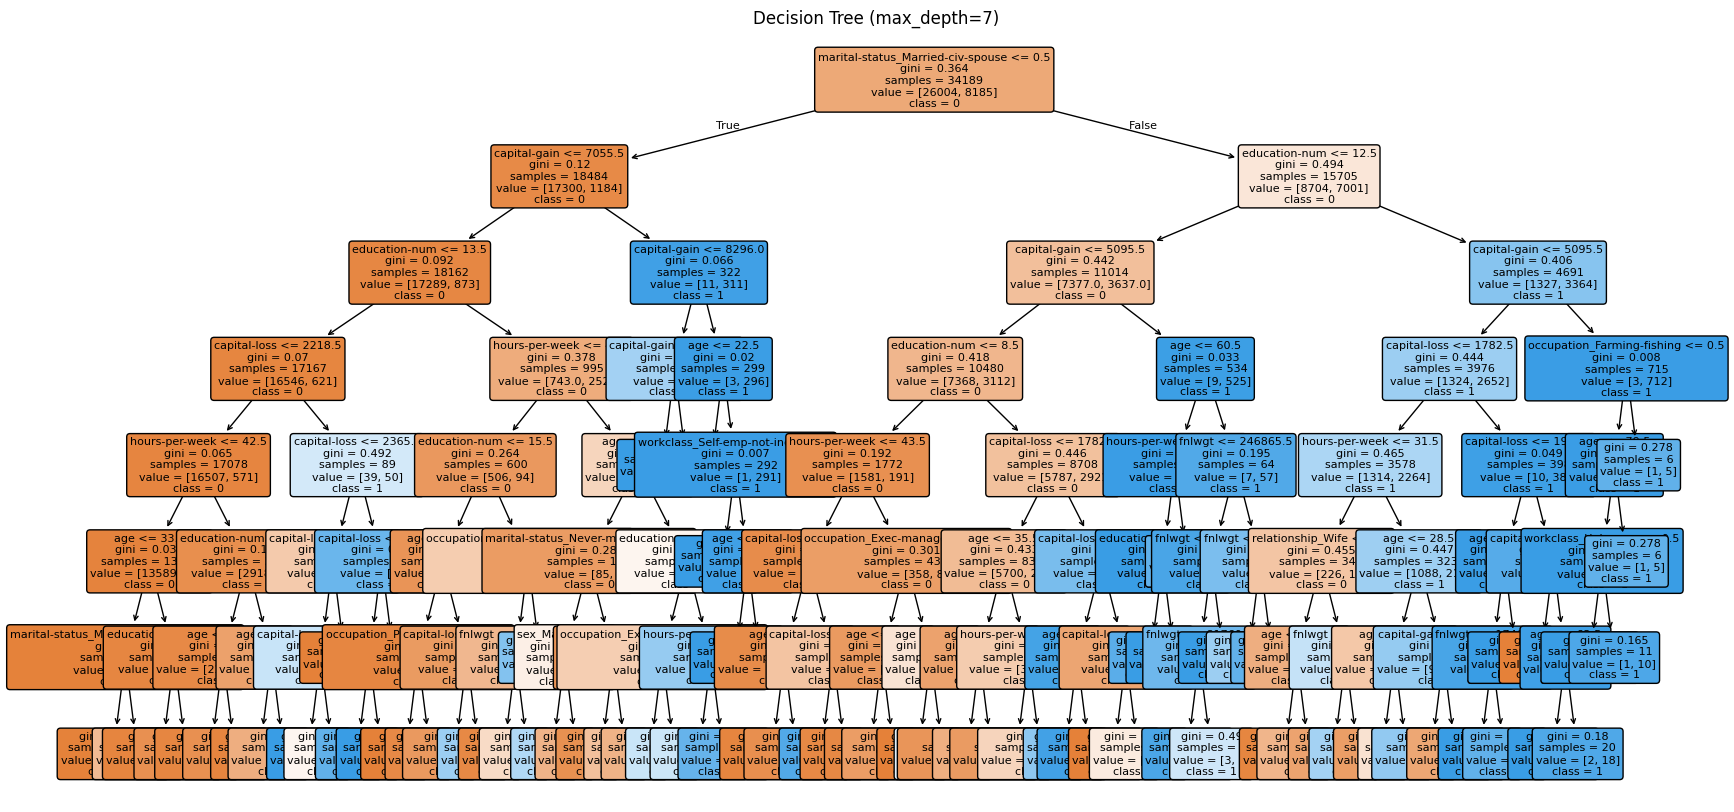

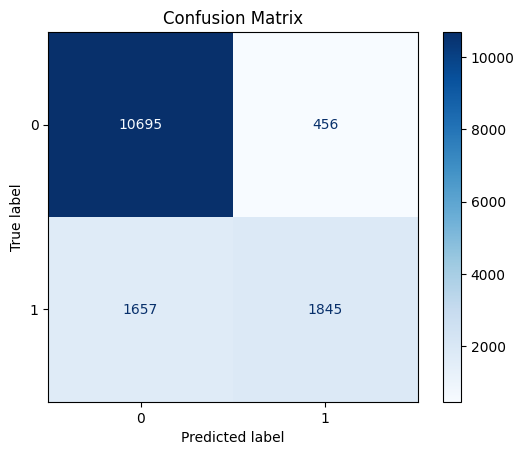

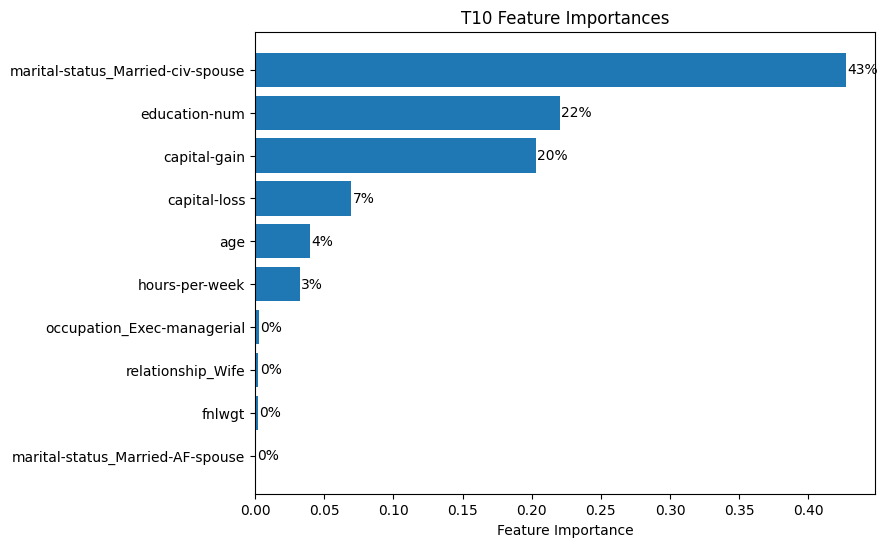

In [35]:
tuned_tree2 = tuned_dt(X_encoded, y_clean_binary,criterion_val="gini",splitter_val="best",max_depth_val=7,
             min_samples_split_val=6,min_samples_leaf_val=6,test_size=0.3,random_state=4000)

Results (max_depth=10)
Accuracy:  0.8470
Precision: 0.7845
Recall:    0.5134


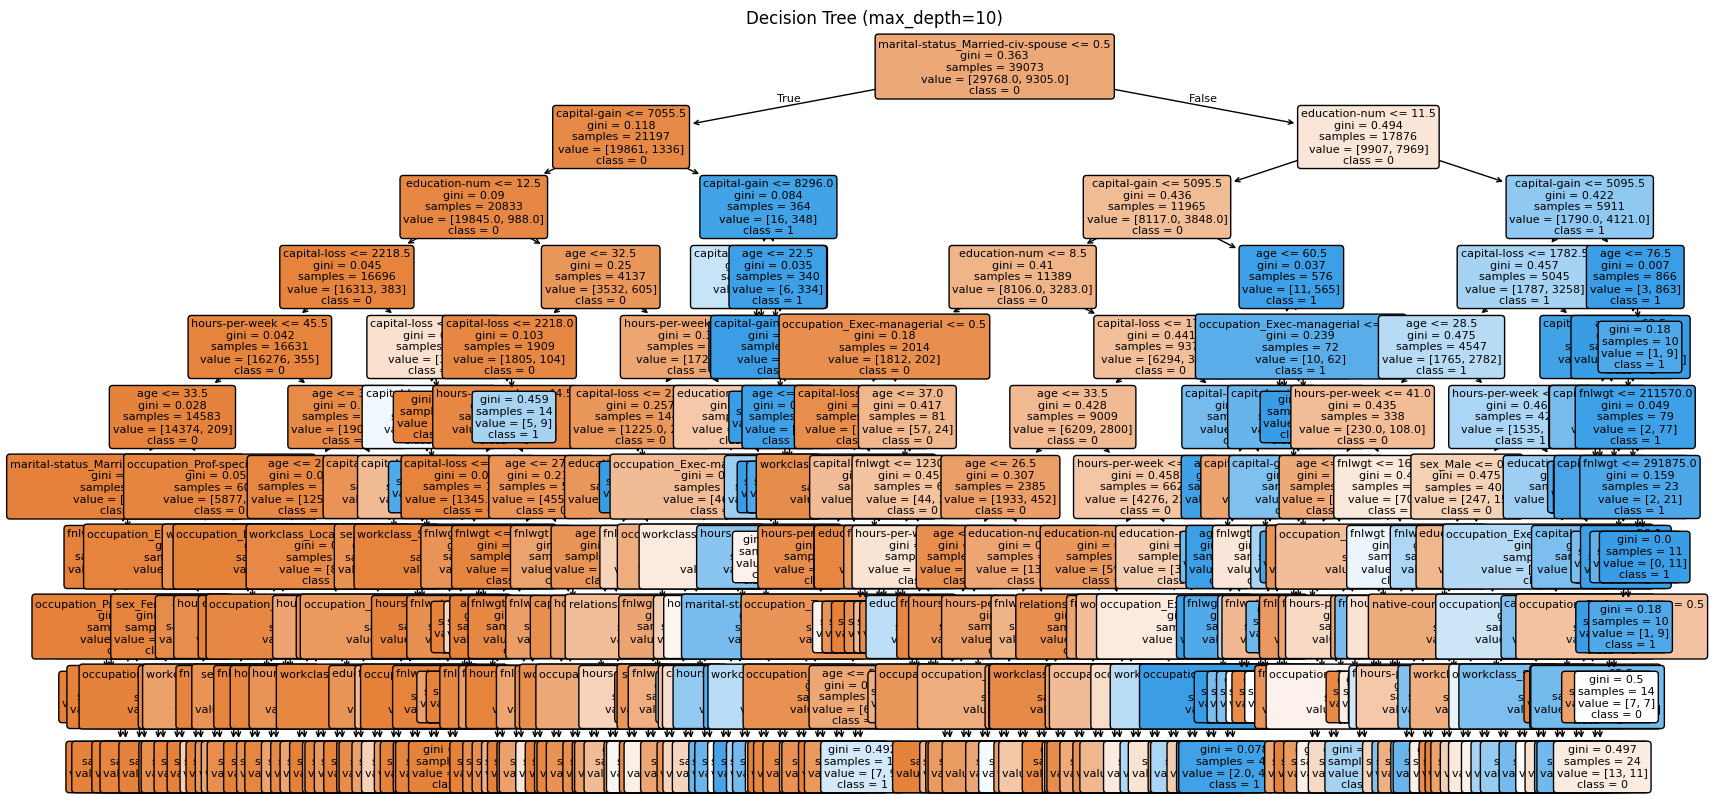

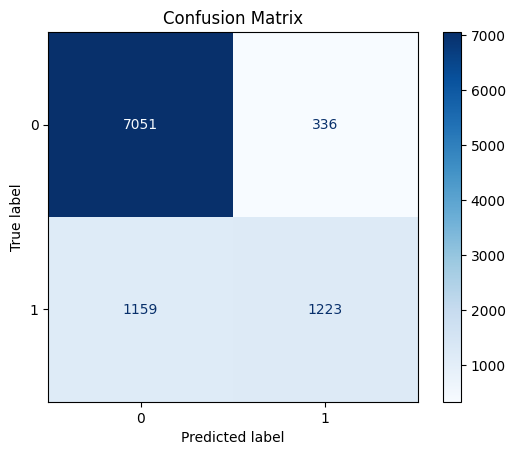

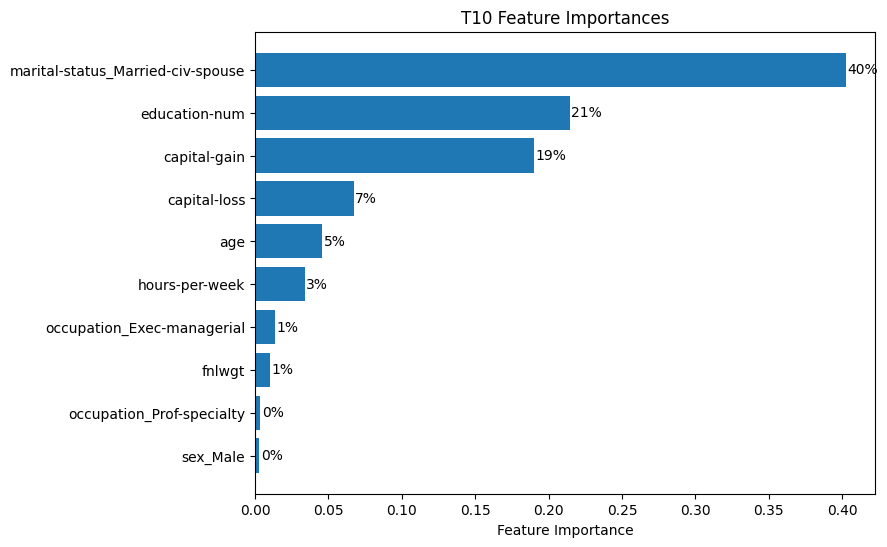

In [32]:
tuned_tree3 = tuned_dt(X_encoded, y_clean_binary,criterion_val="gini",splitter_val="best",max_depth_val=10,
             min_samples_split_val=10,min_samples_leaf_val=10,test_size=0.2,random_state=5000)

**My stategy was to first pick was to lower max depth a little while slightly elevating the other numbers except for random state. I followed with increasing each parameter sligthly each time. Increasing them too much though ended up lowering our accuracy. Another thing that increased accuracy was changing test size from .2 to .3. I thought that test 3 would end up having the highest accuracy since I saw the trend from test 1 to test 2 but seems there is a happy medium between the test 1 and test 2 that can lead to the best model accuracy.**

# **Part 3: Random Forest and Ensembling Evaluation (40 Points)**

## For Parts 3 and 4, you may pick *your own dataset* or continue with the census data.

## Like above, you will want to reference the documentation as necessary:
### https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


## **Data**
## Use this space to load and call your data for Parts 3 and 4. You are welcome to use your final project data for these sections.

In [38]:
adult_data = adult

## **Question 1 (10 points):**

## Write a function to take in a feature variable (X) and a target variable (y). In the function, do the following:

* Create a train test split for the variables.
* Instantiate, fit, and predict using a vanilla Decision Tree
* Instantiate, fit, and predict using a vanilla Random Forest classifier.
* Return and print the accuracy, precision, and recall for both models in any format you wish.

## Call your function and describe your baseline results.


In [40]:
def rf_func(X, y, random_state=3001):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state)

    dt_final = DecisionTreeClassifier(criterion="gini", random_state=random_state)
    dt_final.fit(X_train, y_train)
    y_dt_final_pred = dt_final.predict(X_test)

    rf = RandomForestClassifier(random_state=random_state)
    rf.fit(X_train, y_train)
    y_rf_pred = rf.predict(X_test)

    results = {
        "Decision Tree": {
            "Accuracy": accuracy_score(y_test, y_dt_final_pred),
            "Precision": precision_score(y_test, y_dt_final_pred, average="macro"),
            "Recall": recall_score(y_test, y_dt_final_pred, average="macro")},
        "Random Forest": {
            "Accuracy": accuracy_score(y_test, y_rf_pred),
            "Precision": precision_score(y_test, y_rf_pred, average="macro"),
            "Recall": recall_score(y_test, y_rf_pred, average="macro")}}

    for model_name, metrics_dict in results.items():
        print(f"{model_name}")
        for metric, value in metrics_dict.items():
            print(f"{metric}: {round(value, 4)}")
        print()
    return dt_final, rf

tree_model, rf_model = rf_func(X_encoded, y_clean_binary)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Decision Tree
Accuracy: 0.8069
Precision: 0.7352
Recall: 0.7398

Random Forest
Accuracy: 0.855
Precision: 0.8098
Recall: 0.7739




## **Question 2 (30 points):**
## This question will ask you to tune Random Forest classifiers and preprocess your data in *any number of ways* to achieve the *best possible results you can*.

## Train one vanilla Decision Forest model and one vanilla Random Forest model and store their accuracies in variables so you can use them as baselines.

## Then, using functions or not, spend some time tuning at least 10 (or more) Random Forest models. Store your accuracies in a list or array and print your maximum accuracy.

# **Go crazy - feel free to implement sampling, dropping features, preprocessing, new parameters, whatever might boost your accuracy.**

# **The top 5 best accuracies in the class will get +15 on their individual lab grade!**

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_clean_binary,test_size=0.3,random_state=4000)

tb = DecisionTreeClassifier(random_state=4000)
tb.fit(X_train, y_train)
y_tb = tb.predict(X_test)
tree_acc = accuracy_score(y_test, y_tb)

fb = RandomForestClassifier(random_state=4000)
fb.fit(X_train, y_train)
y_fb = fb.predict(X_test)
rf_acc = accuracy_score(y_test, y_fb)

print(f"Baseline Decision Tree Accuracy: {tree_acc:.4f}")
print(f"Baseline Random Forest Accuracy: {rf_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline Decision Tree Accuracy: 0.8164
Baseline Random Forest Accuracy: 0.8556


In [44]:
def tune_rf(X, y, param_grid, random_state=4000):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state)

    accuracies = []
    models = []

    for params in param_grid:
        rf = RandomForestClassifier(random_state=random_state, **params)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)
        models.append(rf)

    best_model = models[accuracies.index(max(accuracies))]
    return accuracies, best_model


In [57]:
from sklearn.model_selection import ParameterGrid

# Your existing param_grid (dictionary of lists)
param_grid_dict = {
    "n_estimators": [50, 100],
    "max_features": ["sqrt"],
    "max_depth": [10, 20],
    "min_samples_split": [10, 15],
    "min_samples_leaf": [20, 25]
}

# Generate a list of dictionaries for each parameter combination
param_grid_list = list(ParameterGrid(param_grid_dict))

# Now call tune_rf with the correctly formatted param_grid_list
accuracies, best_rf_model = tune_rf(X_encoded, y_clean_binary, param_grid_list)

print(f"All accuracies from tune_rf: {accuracies}")
print(f"Maximum accuracy from tune_rf: {max(accuracies):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

All accuracies from tune_rf: [0.855114993516686, 0.8555244659796629, 0.855114993516686, 0.8555244659796629, 0.8550467481061899, 0.8545007848222207, 0.8550467481061899, 0.8545007848222207, 0.8590049819149662, 0.8590049819149662, 0.8590049819149662, 0.8590049819149662, 0.8573670920630587, 0.8583225278100047, 0.8573670920630587, 0.8583225278100047]
Maximum accuracy from tune_rf: 0.8590


In [61]:
display(accuracies)
#16 models tested

[0.855114993516686,
 0.8555244659796629,
 0.855114993516686,
 0.8555244659796629,
 0.8550467481061899,
 0.8545007848222207,
 0.8550467481061899,
 0.8545007848222207,
 0.8590049819149662,
 0.8590049819149662,
 0.8590049819149662,
 0.8590049819149662,
 0.8573670920630587,
 0.8583225278100047,
 0.8573670920630587,
 0.8583225278100047]

# **Part 4: Ensemble Model Interpretation and Reflection (15 Points)**


## **Question 1 (5 points):**
## Create a plot that summarizes the results of your experiments and how they compare to the results of your baseline Decision Tree and Random Forest model.

## You may visualize your results in any type of plot you see fit. Color code your visual in some way so that models that did better than the baseline Random Forest are distinguished from models that did worse.

/tmp/ipython-input-3468276228.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=plot_data, palette=plot_data['Color'].tolist())


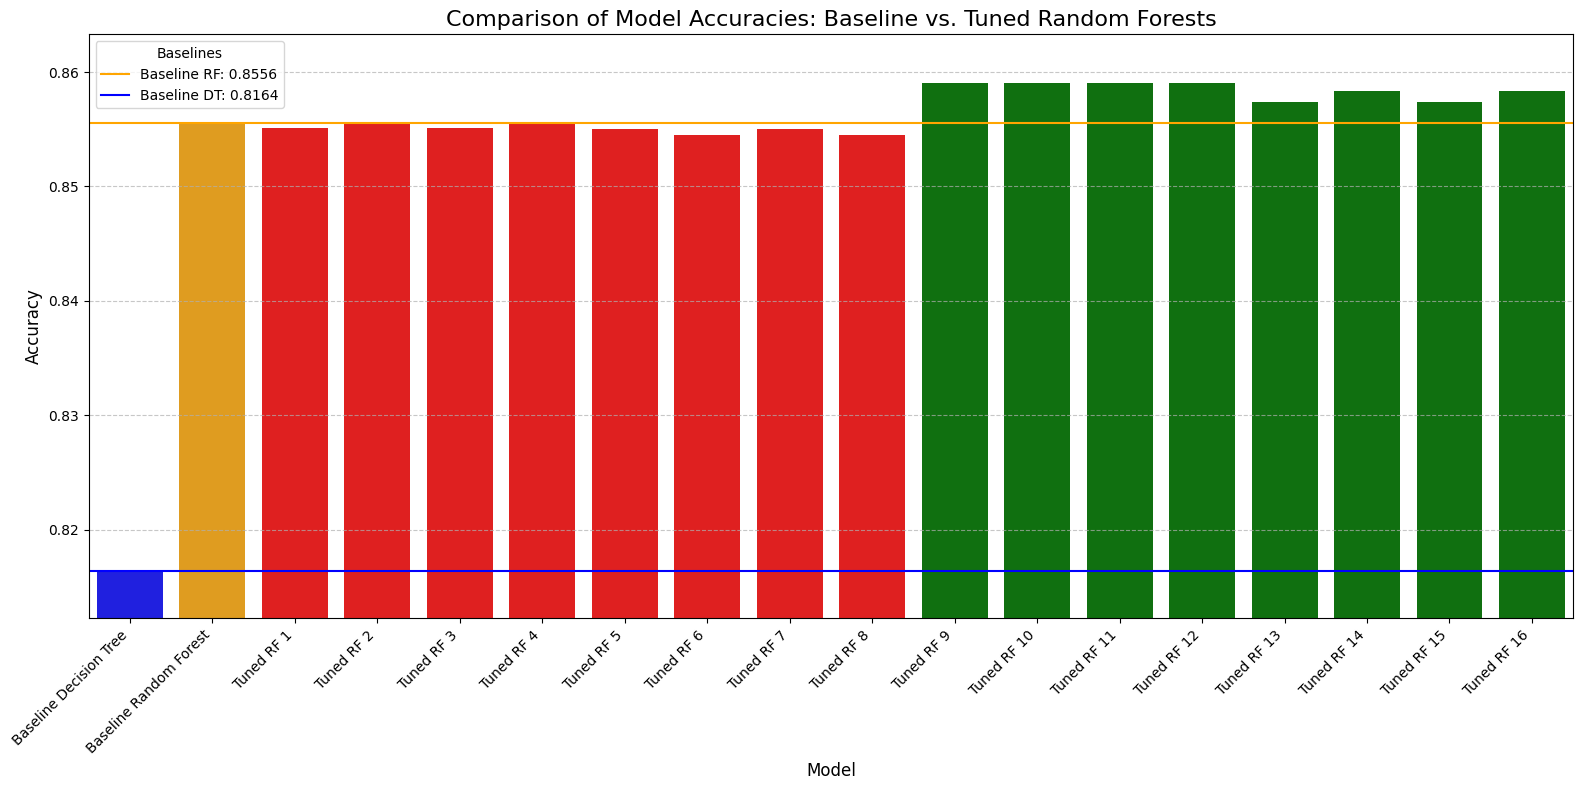

In [68]:
model_labels = ['Baseline Decision Tree', 'Baseline Random Forest'] + [f'Tuned RF {i+1}' for i in range(len(accuracies))]
all_acc_values = [tree_acc, rf_acc] + accuracies

colors = ['blue', 'orange']
for acc in accuracies:
    if acc > rf_acc:
        colors.append('green')
    else:
        colors.append('red')

plot_data = pd.DataFrame({
    'Model': model_labels,
    'Accuracy': all_acc_values,
    'Color': colors
})

plt.figure(figsize=(16, 8))
sns.barplot(x='Model', y='Accuracy', data=plot_data, palette=plot_data['Color'].tolist())

plt.axhline(rf_acc, color='orange', linestyle='-', label=f'Baseline RF: {rf_acc:.4f}')
plt.axhline(tree_acc, color='blue', linestyle='-', label=f'Baseline DT: {tree_acc:.4f}')

plt.title('Comparison of Model Accuracies: Baseline vs. Tuned Random Forests', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(min(all_acc_values) * 0.995, max(all_acc_values) * 1.005)
plt.legend(title='Baselines')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Question 2 (5 points):**
## Write 10 or more sentences on what parameters had the biggest effect or did not seem to effect your results. Did any parameter choices make your results worse than your vanilla model?

**The max_depth parameter exerted the strongest influence. This indicated the deep trees (max_depth=20) had the best accuracies, around 0.8590. It shows that even the best performance would require exploring more-complex relationships. min_samples_leaf also proved a key contribution as our result was in a range of 20 and 25, overall 20 is better than 25 in the best performing model. This showed a fine middle distance between tree complexity and overfitting. The n_estimators (number of trees) parameter had a lower (but still noticeable) effect: 100 estimators often produced slightly better results than 50. Contrastingly, min_samples_split ("minimum samples to split") appeared to exert the least effect in 10 to 15, as both values appeared in optimal combinations. It is worth considering that certain parameter combinations did result in the model getting worse than the Random Forest baseline. The accuracies of models with max_depth = 10 and min_samples_leaf = 25 were less than the baseline 0.8556. This highlights that while tuning leads to better results, less than ideal choices can actually degrade performance.**



## **Question 3 (5 points):**
## Write at least 5 sentences reflecting on the tuning process. A few prompts you might choose to answer are below:

*  What kind of approach did you take?
* Was it random combinations or more structured?
* Did you change your approach after seeing your initial results?
*  What kind of strategies in preprocessing and picking parameters (ie: brute forcing parameters, testing various values in a range) do you think would get some of the best scores in the class?

**I tuned in a systematic manner whereby max_depth and other parameters were adjusted progressively, starting from the conservative, low parameters. Because some combinations reduced accuracy, I improved my search to find a balanced model instead of just more complexity. The most promising strategy discovered was to run a systematic test of parameter ranges like a focused grid search. Therefore, for optimal class score, I think it would be necessary to ensure some combination of the extensive preprocessing with a broader grid search or random search in more parameter space. Further, a cross-validation integration would bring a more effective assessment of the model performance.**



### Honor Pledge

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.